<a href="https://colab.research.google.com/github/aledisanto/scene_recognition_project/blob/main/Computer_Vision_progetto_Di_Santo_Alessandro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INIZIALIZZAZIONE**  

Andiamo inizialmente a scaricare ed estrarre il **dataset**


In [ ]:
import os

# scarichiamo il file zip da Dropbox
DROPBOX_LINK = "https://www.dropbox.com/scl/fi/l45czofnkc775elrq6494/CVPR2023_project_2_and_3_data.zip?rlkey=fe592t8me27xn8igeehslo995&st=oail04s5&dl=1"

# scarichiamo il file e lo rinominiamo "dataset.zip"
!wget -O dataset.zip {DROPBOX_LINK}

# decomprimiamo il file zip all'interno di una cartella che denominiamo "data"
!unzip -q -o dataset.zip -d data/

# stampiamo sullo schermo il contenuto della cartella appena definita
print("Dataset estratto in 'data/'. Struttura cartelle:")
!ls data/

--2026-09-16 21:47:54--  https://www.dropbox.com/scl/fi/l45czofnkc775elrq6494/CVPR2023_project_2_and_3_data.zip?rlkey=fe592t8me27xn8igeehslo995
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc24f785407db591cd3abdc89c26.dl.dropboxusercontent.com/cd/0/inline/DIRDtB_Modb50VaCf9Gg2s9q74XfBldyl_e9AW8TEgFGG7KpzswSy7dhp6SKwRm0Ueu2Pdd1jceep_99TTvEPTg6ffu3LNFpnFvpQcvhO-AIjqEng64zOQE1MeO2ufgxyJBozFoG4ZP5XK5wGia04r0R/file# [following]
--2026-09-16 21:47:55--  https://uc24f785407db591cd3abdc89c26.dl.dropboxusercontent.com/cd/0/inline/DIRDtB_Modb50VaCf9Gg2s9q74XfBldyl_e9AW8TEgFGG7KpzswSy7dhp6SKwRm0Ueu2Pdd1jceep_99TTvEPTg6ffu3LNFpnFvpQcvhO-AIjqEng64zOQE1MeO2ufgxyJBozFoG4ZP5XK5wGia04r0R/file
Resolving uc24f785407db591cd3abdc89c26.dl.dropboxusercontent.com (uc24f785407db591cd3abdc89c26.dl.dropboxusercontent.com)...

**FASE 1**  

In questa prima fase del progetto l'obiettivo è stabilire un punto di riferimento (baseline) andando a costruire un Rete Neurale Convoluzionale (CNN) da zero.  

**Architettura della Rete**:  
andiamo ad implementare il layout descritto nella Tabella 1. La rete agirà come un estrattore di feature seguito da un classificatore:  


*   **Input**: le immagini saranno convertite in scala per avere una dimensione 64x64x1
*   **3 blocchi convoluzionali**: ogni blocco applica una convoluzione con filtri 3x3, seguita da una funzione di attivazione non lineare ReLU e da un Max Pooling 2x2 per dimezzare le dimensioni spaziali.  
*OSS.* --> il numero di filtri aumenta progressivamente (8 - 16 - 32) per catturare feature sempre più complesse

*   **Classificazione**: avviene attraverso un singolo livello Fully Connected che mapperà le feature estratte sulle 15 classi di output  

**Preprocessing dei Dati**:  


*   **Riscalamento**: tutte le immagini devono essere ridimensionate a 64x64 pixel  

*Assenza di Normalizzazione standard* -->  la consegna specifica di evitare la normalizzazione standard  

**Inizializzazione e Ottimizzazione**:  



*   i bias devono essere inizializzati a 0, mentre i pesi convoluzionali e lineare devono essere campionati da una distribuzione Gaussiana con **media** pari a *0* e **deviazione standard** pari a *0.01*

*   l'addestramento userà la **Discesa del Gradiente Stocastico (SGD)** con l'aggiunta del momentum, utilizzando un minibatch da 32 campioni

*   il training set originale sarà diviso dinamicamente come segue: *85%* per l'**addestramento dei pesi** e il *15%* per il **validation set** (per monitorare l'overfitting)















In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import copy

# fissiamo il seed per garantire la riproducibilità dei risultati
torch.manual_seed(42)

# definizione del preprocessing
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # (scala di grigi)
    transforms.Resize((64, 64)),                 # Rescaling forzato a 64x64
    transforms.ToTensor(),                       # Converte l'immagine in un tensore (valori [0.0, 1.0])
    transforms.Lambda(lambda x: x * 255.0)       # Moltiplica per 255 per riportare i pixel nel range [0, 255]
])

# estrazione e caricamento dati
train_dir = 'data/train'
test_dir = 'data/test'

# caricamento del training set completo
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

# 85% Training, 15% Validation
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# creazione di minibatch da 32
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = full_train_dataset.classes

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convoluzione 1: 8 filtri 3x3. Uso padding=1 per mantenere la dim spaziale 64x64 prima del pooling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Dimezza a 32x32

        # Convoluzione 2: 16 filtri 3x3
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Dimezza a 16x16

        # Convoluzione 3: 32 filtri 3x3
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Dimezza a 8x8

        # Layer Fully Connected.
        # Dimensioni in ingresso: 32 canali * 8 altezza * 8 larghezza = 2048 feature
        self.fc = nn.Linear(in_features=32 * 8 * 8, out_features=15)

        # Inizializzazione pesi
        self._initialize_weights()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = torch.flatten(x, 1) # Appiattisce i tensori spaziali in un vettore
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        # Itera su tutti i sottomoduli della rete
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01) # Pesi da Gaussiana(0, 0.01)
                nn.init.constant_(m.bias, 0.0)                # Bias a 0

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

In [ ]:
# Funzione di costo e ottimizzatore
criterion = nn.CrossEntropyLoss()

# Iniziamo con un learning rate piccolo a causa dei valori [0, 255] in input
learning_rate = 1e-4
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

num_epochs = 40

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # --- TRAINING ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # --- VALIDATION ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Stopping criterion logico: Salviamo i pesi dell'epoca con la Loss di validazione minore
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

    print(f'Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%')

# Ripristiniamo i pesi migliori (Stopping Criterion per prevenire overfitting finale)
model.load_state_dict(best_model_weights)

Epoch 01/40 | Train Loss: 1.6039 Acc: 48.31% | Val Loss: 2.1307 Acc: 36.89%
Epoch 02/40 | Train Loss: 1.6635 Acc: 46.82% | Val Loss: 2.3355 Acc: 33.78%
Epoch 03/40 | Train Loss: 1.5891 Acc: 48.39% | Val Loss: 2.2430 Acc: 35.11%
Epoch 04/40 | Train Loss: 1.5981 Acc: 47.76% | Val Loss: 2.2864 Acc: 34.67%
Epoch 05/40 | Train Loss: 1.5199 Acc: 49.65% | Val Loss: 2.2167 Acc: 36.44%
Epoch 06/40 | Train Loss: 1.4570 Acc: 52.31% | Val Loss: 2.0940 Acc: 39.11%
Epoch 07/40 | Train Loss: 1.4688 Acc: 51.61% | Val Loss: 2.0879 Acc: 39.11%
Epoch 08/40 | Train Loss: 1.4338 Acc: 52.71% | Val Loss: 2.2224 Acc: 36.44%
Epoch 09/40 | Train Loss: 1.3480 Acc: 58.12% | Val Loss: 2.3273 Acc: 36.89%
Epoch 10/40 | Train Loss: 1.3452 Acc: 55.53% | Val Loss: 2.3437 Acc: 35.56%
Epoch 11/40 | Train Loss: 1.3826 Acc: 55.06% | Val Loss: 2.2641 Acc: 36.89%
Epoch 12/40 | Train Loss: 1.3160 Acc: 57.41% | Val Loss: 2.2828 Acc: 36.00%
Epoch 13/40 | Train Loss: 1.2676 Acc: 57.18% | Val Loss: 2.3344 Acc: 35.56%
Epoch 14/40 

<All keys matched successfully>

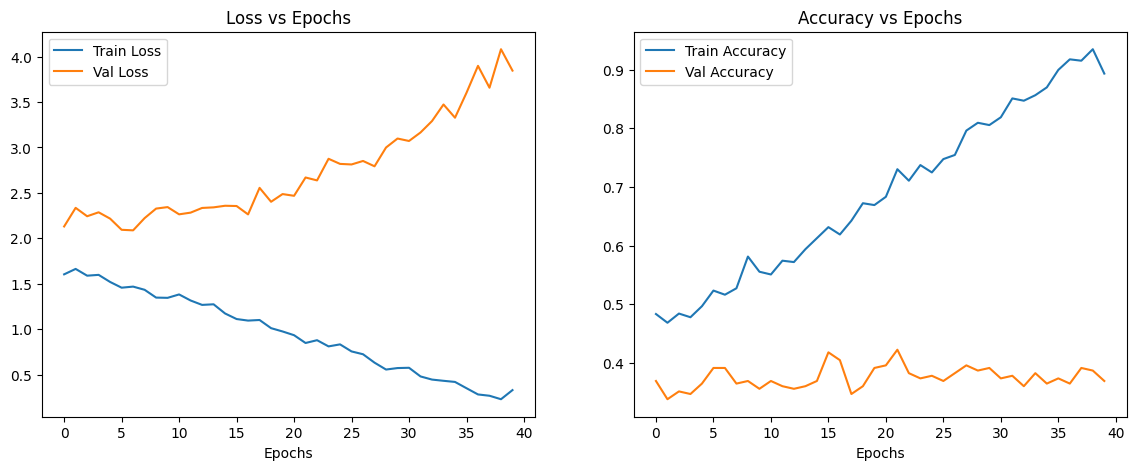


Overall Test Accuracy: 31.76% (Obiettivo: ~30%)


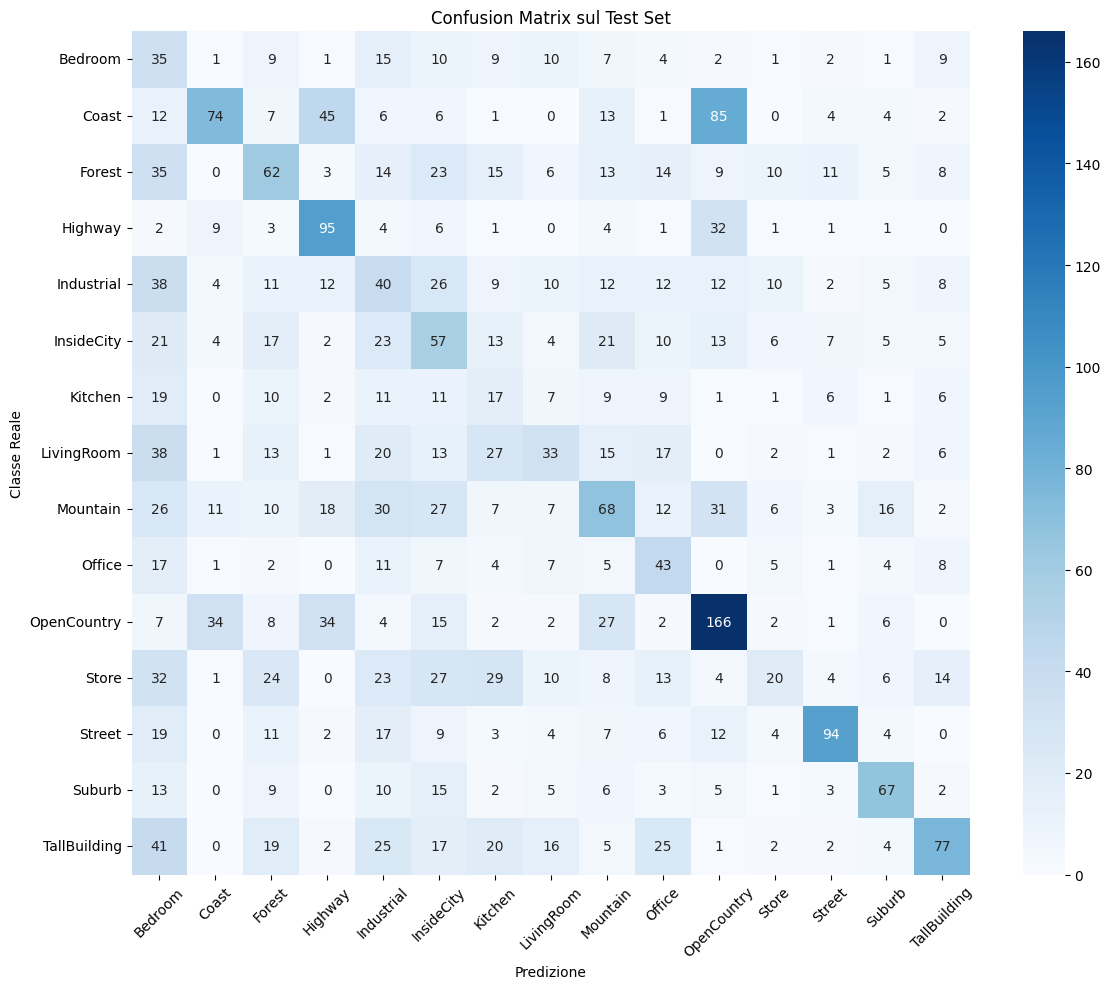

In [ ]:
# Plot Loss e Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Test Set Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {test_accuracy * 100:.2f}% (Obiettivo: ~30%)")

# Matrice di Confusione
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix sul Test Set')
plt.xlabel('Predizione')
plt.ylabel('Classe Reale')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**FASE 2**  

Per incrementare le performance e raggiungere il target del 60%, la consegna suggerisce le seguenti tecniche avanzate:  


*   **Riflessione Orizzontale**: siccome il dataset è di dimensioni ridotte, genereremo delle "nuove" immagini andando ad applicare una riflessione speculare sinistra-destra (*Horizontal Flip*).  
*OSS.* --> questa trasformazione dovrà essere applicata esclusivamente sul training set  

*   **Batch Normalization**: introdurreremo il layer di Batch Normalization subito prima del layer di attivazione ReLU. Tale processo normalizza l'output del livello convoluzionale precedente, stabilizzando e accelerando la convergenza dell'addestramento (riducendo il cosiddetto *internal covariate shift*)  


*   **Dropout**: per contrastare l'*overfitting*, aggiungeremo un layer di Dropout prima del classificatore finale (Fully Connected). Il Dropout "spegne" casualmente una percentuale di neuroni ad ogni iterazione, constringendo la rete a imparare feature più robuste e distribuite invece di affidarsi a pochi nodi specifici  

*   **Architettura e Filtri**: come suggerito dalla consegna, possiamo aumentare la dimensione o il numero dei filtri. Raddoppieremo il numero di feature map estratte nei tre blocchi convoluzionali (es. 16 - 32 - 64) per dare alla rete maggiore capacità espressiva.  


*   **Adam Optimizer**: sostituiremo lo SGD con Adam, che adatta dinamicamente il learning rate per ogni singolo parametro, garantendo solitamente un apprendimento molto più rapido e stabile nelle reti convoluzionali profonde.







In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

torch.manual_seed(42)

# Trasformazione per il TRAINING (include Data Augmentation)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5), # Left-to-right reflection richiesta
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 255.0)
])

# Trasformazione per VALIDATION e TEST (SOLO rescaling)
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 255.0)
])

# Caricamento dati
train_dir = 'data/train'
test_dir = 'data/test'

# Carichiamo il dataset due volte per applicare trasformazioni diverse al Training e al Validation Set
full_dataset_train_aug = datasets.ImageFolder(root=train_dir, transform=train_transform)
full_dataset_eval = datasets.ImageFolder(root=train_dir, transform=eval_transform)

# Costruzione del Training Set e del Validation Set
dataset_size = len(full_dataset_train_aug)
train_size = int(0.85 * dataset_size)
val_size = dataset_size - train_size

# Generiamo una permutazione casuale degli indici
indices = torch.randperm(dataset_size).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Assegniamo a ciascuno la propria trasformazione
train_dataset = Subset(full_dataset_train_aug, train_indices)
val_dataset = Subset(full_dataset_eval, val_indices)

test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transform)

# Creazione dei minibatch
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        # Blocco 1 (Aumentiamo a 16 filtri)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # Batch Norm prima della ReLU
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Blocco 2 (Aumentiamo a 32 filtri)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Blocco 3 (Aumentiamo a 64 filtri)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Classificatore con Dropout
        self.dropout = nn.Dropout(p=0.5)
        # Input features = 64 canali * 8 * 8 (dopo tre pooling da 64x64)
        self.fc = nn.Linear(64 * 8 * 8, 15)

        self._initialize_weights()

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(x) # Applichiamo dropout prima del layer lineare
        x = self.fc(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.constant_(m.bias, 0.0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedCNN().to(device)

In [ ]:
import copy

# Ottimizzazione e Addestramento
criterion = nn.CrossEntropyLoss()

# Passiamo ad Adam
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 40
best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

    print(f'Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%')

# Ripristino pesi migliori
model.load_state_dict(best_model_weights)

Epoch 01/40 | Train Loss: 2.6608 Acc: 18.12% | Val Loss: 2.2211 Acc: 27.56%
Epoch 02/40 | Train Loss: 2.0131 Acc: 36.00% | Val Loss: 1.8722 Acc: 44.44%
Epoch 03/40 | Train Loss: 1.7234 Acc: 45.33% | Val Loss: 1.9606 Acc: 40.44%
Epoch 04/40 | Train Loss: 1.4431 Acc: 51.53% | Val Loss: 2.0694 Acc: 35.11%
Epoch 05/40 | Train Loss: 1.3135 Acc: 57.65% | Val Loss: 1.9001 Acc: 45.78%
Epoch 06/40 | Train Loss: 1.1985 Acc: 61.02% | Val Loss: 2.3357 Acc: 30.22%
Epoch 07/40 | Train Loss: 1.0907 Acc: 62.82% | Val Loss: 1.4408 Acc: 52.89%
Epoch 08/40 | Train Loss: 0.9621 Acc: 68.55% | Val Loss: 1.7038 Acc: 48.89%
Epoch 09/40 | Train Loss: 0.9203 Acc: 68.63% | Val Loss: 1.7722 Acc: 45.78%
Epoch 10/40 | Train Loss: 0.9057 Acc: 68.16% | Val Loss: 1.4125 Acc: 58.22%
Epoch 11/40 | Train Loss: 0.7970 Acc: 74.35% | Val Loss: 1.7263 Acc: 50.67%
Epoch 12/40 | Train Loss: 0.7352 Acc: 74.82% | Val Loss: 1.1937 Acc: 65.33%
Epoch 13/40 | Train Loss: 0.6543 Acc: 78.82% | Val Loss: 2.0188 Acc: 40.00%
Epoch 14/40 

<All keys matched successfully>

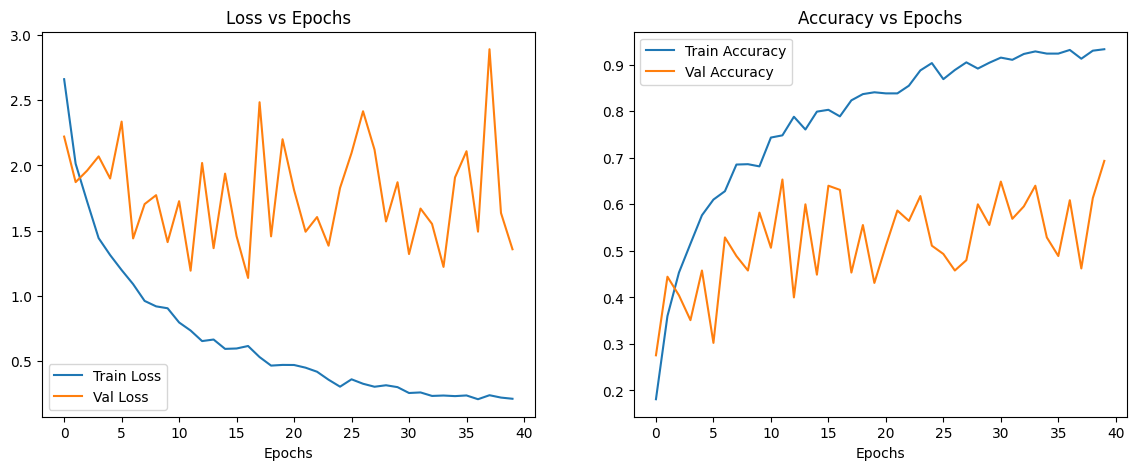


Overall Test Accuracy: 59.93% (Obiettivo: ~60%)


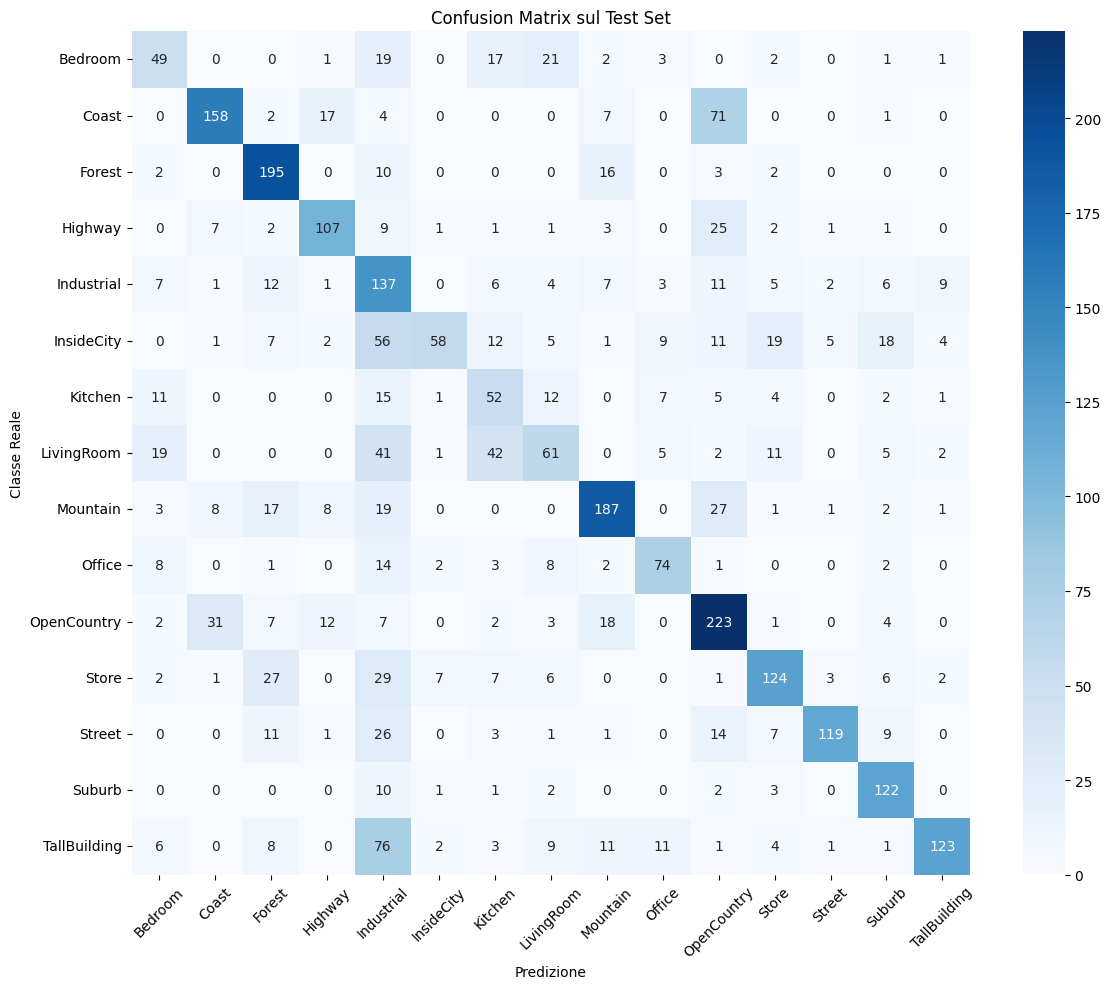

In [ ]:
# Plot Loss e Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Test Set Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {test_accuracy * 100:.2f}% (Obiettivo: ~60%)")

# Matrice di Confusione
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix sul Test Set')
plt.xlabel('Predizione')
plt.ylabel('Classe Reale')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**FASE 3**  
Invece di addestrare una rete partendo da pesi casuali (come abbiamo fatto nei punti precedenti), prenderemo un'architettura complessa e già addestrata su milioni di immagini, nello specifico **AlexNet**. Avendo già imparato a riconoscere bordi e pattern visivi complessi su un dataset enorme (**ImageNet**), tale rete possiede una conoscenza di base che "trasferiremo" al nostro problema specifico delle 15 classi di scene.  

Andiamo ad implementare due approcci distinti:  



*   **Approccio 1: Fine-Tuning dell'ultimo layer**. Prenderemo il modello AlexNet e "congeleremo" i pesi di tutti i suoi livelli, in modo che non vengano modificati durante l'addestramento. Siccome AlexNet è progettato per classificare 1000 categorie, rimuoveremo il suo ultimo livello (*fully connected*) e lo sostituiremo con un nuovo livello lineare inizializzato casualmente, avente 15 output (le nostre classi). Addestreremo *solo* quest'ultimo livello utilizzando i nostri set di training e di validation.  

*  **Approccio 2: Feature Extraction e SVM**. In questo caso, non useremo affatto algoritmi di discesa del gradiente per addestrare la rete. Useremo AlexNet "coì com'è". Ci fermeremo a un livello intermedio (uno dei layer fully connected prima dell'output) per estrarre le "attivazioni", ovvero un vettore numerico che rappresenta le feature dell'immagine estratte dalla rete. Utilizzeremo poi questi vettori per addestrare un classificatore classico: una SVM lineare multiclasse.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import numpy as np

# Pre-processing delle immagini (riscalamento a 224x224 per Alexnet) per il testing
alexnet_transform = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet richiede immagini 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Caricamento dei dati
train_dir = 'data/train'
test_dir = 'data/test'

# Suddivisione in training set e validation set
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=alexnet_transform)
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

test_dataset = datasets.ImageFolder(root=test_dir, transform=alexnet_transform)

# Creazione dei minibatch
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# APPROCCIO 1

# Carichiamo AlexNet pre-addestrata
model_ft = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Congeliamo tutti i parametri
for param in model_ft.parameters():
    param.requires_grad = False

# Modifichiamo l'ultimo layer del classificatore
num_ftrs = model_ft.classifier[6].in_features
model_ft.classifier[6] = nn.Linear(num_ftrs, 15)

model_ft = model_ft.to(device)

# Ottimizzazione dell'addestramento
optimizer_ft = optim.Adam(model_ft.classifier[6].parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Addestramento breve (il transfer learning converge molto velocemente)
num_epochs_ft = 10


for epoch in range(num_epochs_ft):
    model_ft.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        outputs = model_ft(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    print(f'Epoch {epoch+1}/{num_epochs_ft} | Train Acc: {correct/total * 100:.2f}%')

# Valutazione finale sul test set
model_ft.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc_ft = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy Fine-Tuning: {acc_ft * 100:.2f}% (Obiettivo > 85%)")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:05<00:00, 44.9MB/s]


Epoch 1/10 | Train Acc: 69.25%
Epoch 2/10 | Train Acc: 90.51%
Epoch 3/10 | Train Acc: 93.02%
Epoch 4/10 | Train Acc: 95.84%
Epoch 5/10 | Train Acc: 95.84%
Epoch 6/10 | Train Acc: 97.18%
Epoch 7/10 | Train Acc: 97.73%
Epoch 8/10 | Train Acc: 98.20%
Epoch 9/10 | Train Acc: 98.27%
Epoch 10/10 | Train Acc: 98.51%
Test Accuracy Fine-Tuning: 86.06% (Obiettivo > 85%)


In [ ]:
# APPROCCIO 2

# Ricostruiamo AlexNet pre-addestrata
model_fe = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
model_fe = model_fe.to(device)
model_fe.eval() # Solo valutazione, nessun calcolo dei gradienti

# Rimuoviamo l'ultimo livello per accedere alle attivazioni intermedie
model_fe.classifier[6] = nn.Identity()

# Funzione per estrarre le feature da un intero DataLoader
def extract_features(dataloader, model):
    features_list = []
    labels_list = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            features = model(inputs)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())

    # Concateniamo i risultati
    return np.vstack(features_list), np.concatenate(labels_list)

X_train, y_train = extract_features(train_loader, model_fe)
X_test, y_test = extract_features(test_loader, model_fe)
print(f"Dimensioni feature estratte: Train {X_train.shape}, Test {X_test.shape}")

# Addestramento della SVM Lineare Multiclasse
svm_classifier = LinearSVC(C=1.0, max_iter=10000, random_state=42)
svm_classifier.fit(X_train, y_train)

# Predizione e Valutazione
y_pred = svm_classifier.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred)
print(f"Test Accuracy SVM Multiclasse: {acc_svm * 100:.2f}% (Obiettivo > 85%)")

Dimensioni feature estratte: Train (1275, 4096), Test (2985, 4096)
Test Accuracy SVM Multiclasse: 86.23% (Obiettivo > 85%)
